In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

df = pd.read_csv('/content/Teen_Mental_Health_Dataset.csv')
df = df.dropna()
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

(1200, 13)
Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level 

In [16]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("depression_label", axis=1)
y = df["depression_label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

R2 Score: 0.07334339953843738
MAE: 0.07441426031096769
MSE: 0.022587254636250588


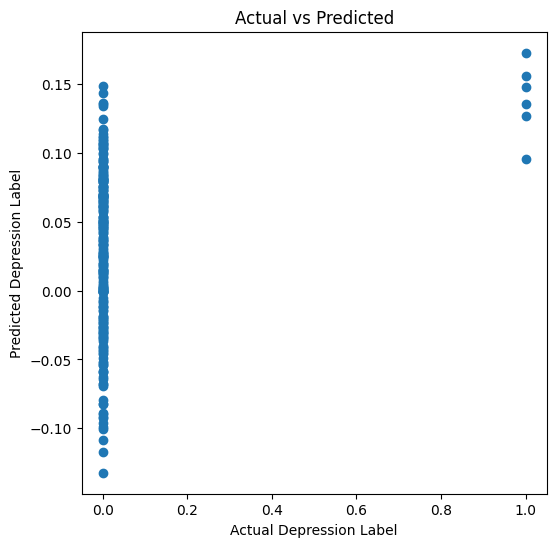

In [18]:
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Depression Label")
plt.ylabel("Predicted Depression Label")
plt.title("Actual vs Predicted")

plt.show()

Accuracy: 0.9833

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       234
           1       0.75      0.50      0.60         6

    accuracy                           0.98       240
   macro avg       0.87      0.75      0.80       240
weighted avg       0.98      0.98      0.98       240


Confusion Matrix:
[[233   1]
 [  3   3]]


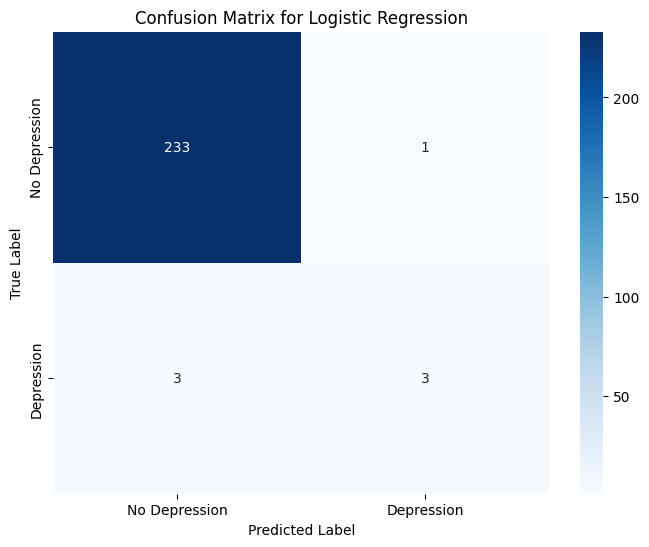

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the Logistic Regression model
log_model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for small datasets
log_model.fit(X_train, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_log)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred_log)
print(conf_matrix)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

## Data Exploration: Distribution and Correlations

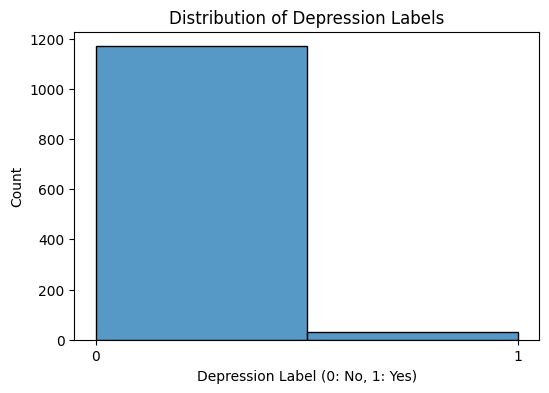

In [20]:
plt.figure(figsize=(6, 4))
sns.histplot(df['depression_label'], bins=2, kde=False)
plt.title('Distribution of Depression Labels')
plt.xlabel('Depression Label (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks([0, 1])
plt.show()

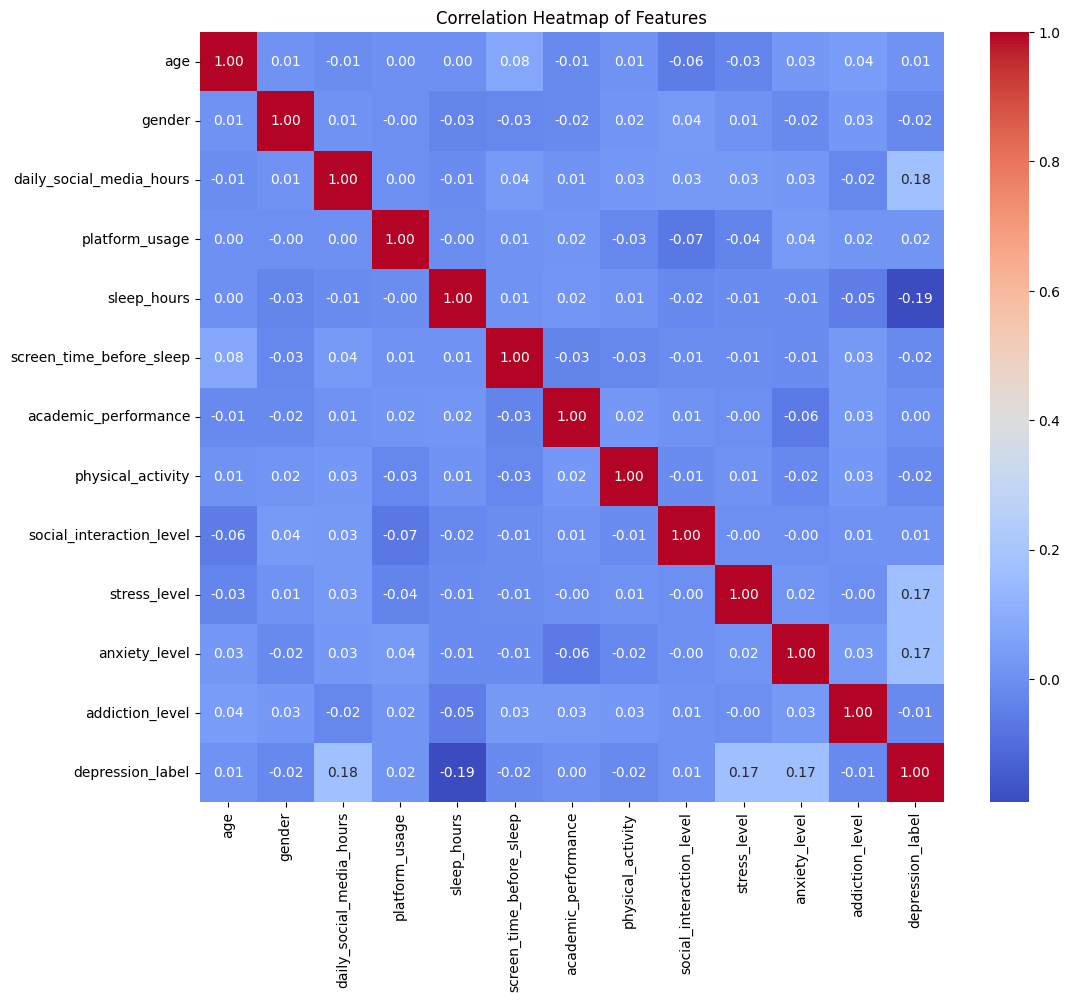

In [21]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

### Feature Distributions vs. Depression Label

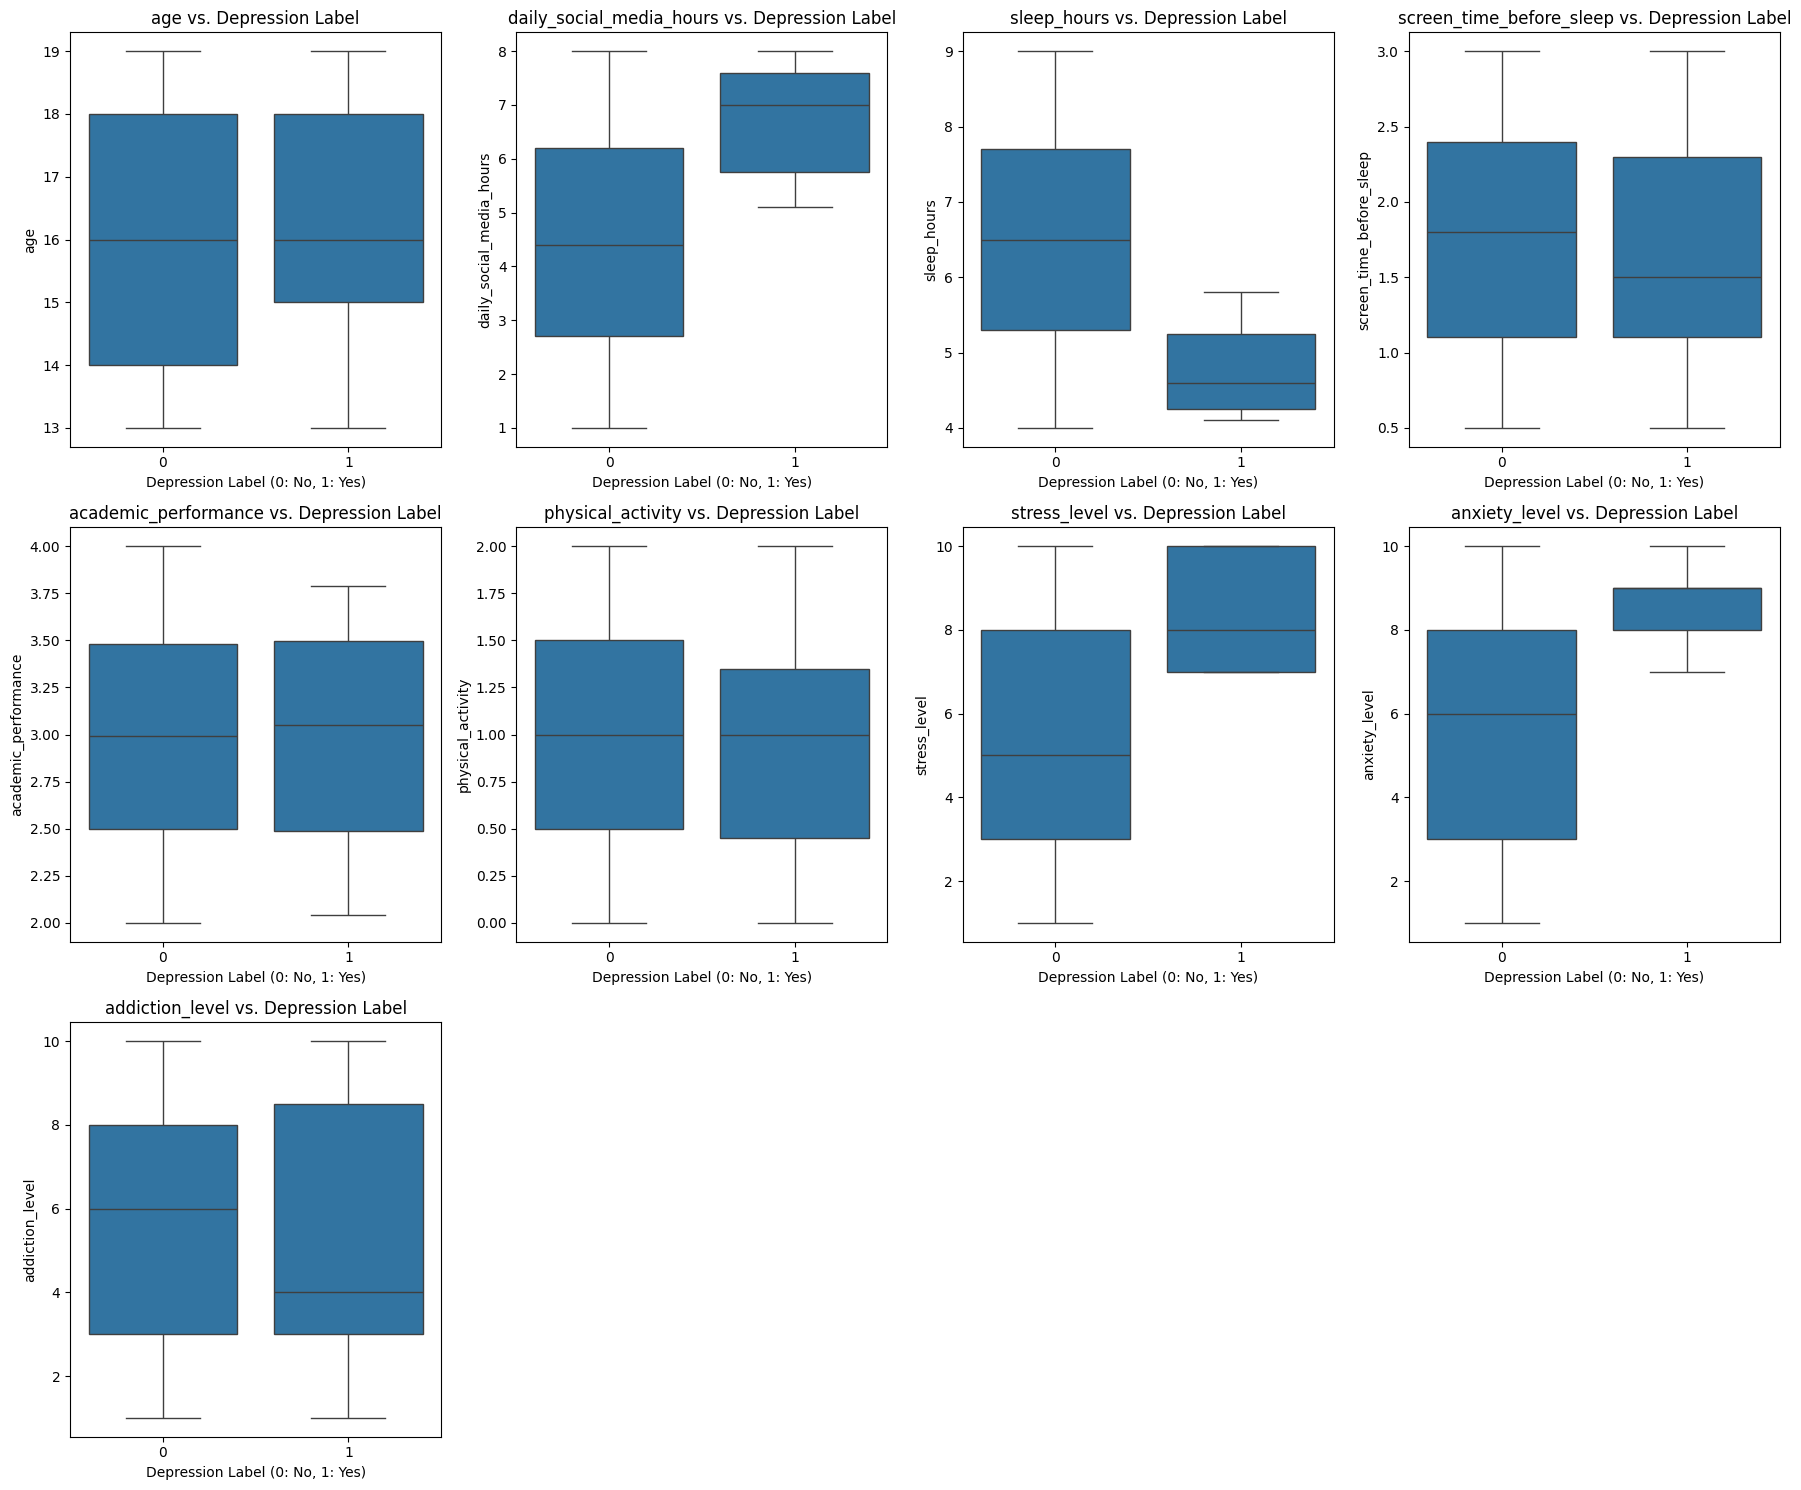

In [22]:
# Box plots for numerical features against depression_label

numerical_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
                  'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']

plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(x='depression_label', y=col, data=df)
    plt.title(f'{col} vs. Depression Label')
    plt.xlabel('Depression Label (0: No, 1: Yes)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Distribution of Categorical Features

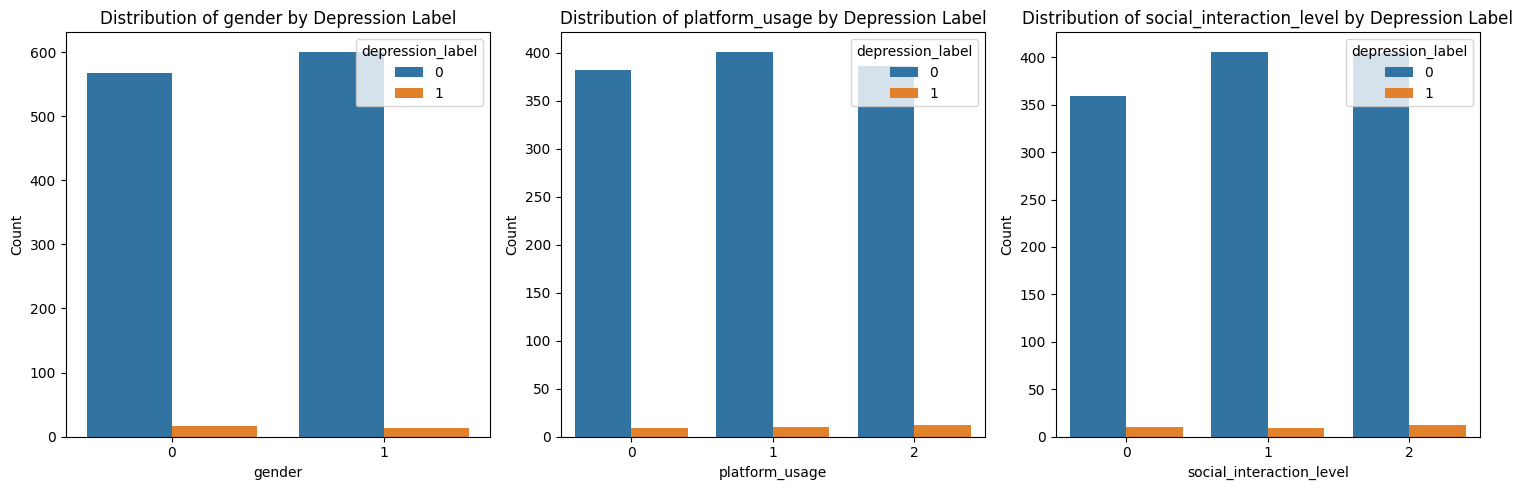

In [23]:
# Count plots for original categorical features (before label encoding if possible, but using encoded here)

categorical_cols = ['gender', 'platform_usage', 'social_interaction_level']

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=col, hue='depression_label', data=df)
    plt.title(f'Distribution of {col} by Depression Label')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()